# 05 — Retrofit Recommendations

**Home Energy Copilot** — CPSC 393 Final Project

We turn classification + regression outputs into **actionable retrofit suggestions** for each test-set household.

**Pipeline (locked in):**
1. Load cleaned RECS data, GBR regression predictions, and the DOE/ENERGY STAR retrofit catalog (`data/upgrade_costs.csv`).
2. For each retrofit, parse the `target_homes` rule into a pandas mask (which households qualify).
3. Compute expected **annual $ savings** as `savings_pct_mid × matching end-use $ column` (end-use specific basis).
4. Compute **simple payback years** = `cost_midpoint / annual_savings`.
5. Surface the **top 5** lowest-payback eligible retrofits per household.
6. Aggregate population-level potential savings (weighted by `NWEIGHT`) by climate group and by efficiency class.

Why end-use-specific savings? Insulation cuts heating/cooling bills, not lighting bills. Applying `savings_pct` to `heat_cool_dol` (instead of `TOTALDOL`) makes the dollar figures physically defensible.

## Setup

In [1]:
import os, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_DIR   = '../data'
MODELS_DIR = '../models'

df       = pd.read_pickle(os.path.join(DATA_DIR, 'recs2020_clean.pkl'))
meta     = json.load(open(os.path.join(DATA_DIR, 'recs2020_clean_meta.json')))
split    = json.load(open(os.path.join(DATA_DIR, 'train_test_split.json')))
upgrades = pd.read_csv(os.path.join(DATA_DIR, 'upgrade_costs.csv'))
preds    = pd.read_csv(os.path.join(MODELS_DIR, 'regression_test_predictions.csv'))

print('df         :', df.shape)
print('upgrades   :', upgrades.shape)
print('predictions:', preds.shape)
upgrades.head(3)


df         : (18495, 69)
upgrades   : (15, 13)
predictions: (3699, 6)


,upgrade_id,upgrade_name,category,cost_low_usd,cost_high_usd,cost_midpoint_usd,savings_pct_low,savings_pct_high,savings_basis,recs_features_affected,target_homes,lifespan_years,source
0,smart_thermostat,Install smart thermostat,Behavioral,100,300,200,0.06,0.10,heat_cool_dol,TYPETHERM,TYPETHERM!=3,12,ENERGY STAR
1,programmable_thermostat,Install programmable thermostat,Behavioral,40,150,90,0.05,0.08,heat_cool_dol,TYPETHERM,TYPETHERM IN (-2;0;1),15,DOE
2,thermostat_setback,Behavioral thermostat setback (no install),Behavioral,0,0,0,0.05,0.10,heat_cool_dol,TEMPHOME|TEMPGONE|TEMPNITE,always_eligible,1,DOE


Two columns referenced by the retrofit catalog (`DOLLAREL`, `WASHLOAD`) were not kept in the 55-feature shortlist. We re-load them from the raw RECS CSV and merge by `DOEID`.

In [2]:
raw = pd.read_csv(os.path.join(DATA_DIR, 'recs2020_public_v7.csv'),
                  usecols=['DOEID', 'DOLLAREL', 'WASHLOAD'])
df = df.merge(raw, on='DOEID', how='left')
print('after merge:', df.shape)
print('missing DOLLAREL :', df['DOLLAREL'].isna().sum())
print('missing WASHLOAD :', df['WASHLOAD'].isna().sum())
df[['DOEID','DOLLAREL','WASHLOAD']].head()


after merge: (18495, 71)
missing DOLLAREL : 0
missing WASHLOAD : 0


,DOEID,DOLLAREL,WASHLOAD
0,100001,"1,955.06",10
1,100002,713.27,1
2,100003,334.51,-2
3,100004,"1,424.86",4
4,100005,"1,087.00",-2


## Restrict to test set and attach predicted TOTALDOL

In [3]:
test_doeid = set(split['test_doeid'])
test = df[df['DOEID'].isin(test_doeid)].copy().reset_index(drop=True)

preds_idx = preds.set_index('DOEID')
test['pred_TOTALDOL'] = test['DOEID'].map(preds_idx['pred_gbr'])

print('test rows           :', len(test))
print('pred coverage       :', f"{test['pred_TOTALDOL'].notna().mean():.1%}")
print('mean true TOTALDOL  : $', f"{test['TOTALDOL'].mean():,.0f}")
print('mean pred TOTALDOL  : $', f"{test['pred_TOTALDOL'].mean():,.0f}")
test[['DOEID','BA_climate_grp','efficiency_class','TOTALDOL','pred_TOTALDOL']].head()


test rows           : 3699
pred coverage       : 100.0%
mean true TOTALDOL  : $ 1,998
mean pred TOTALDOL  : $ 1,999


,DOEID,BA_climate_grp,efficiency_class,TOTALDOL,pred_TOTALDOL
0,100001,Mixed-Dry,inefficient,"2,656.89","2,201.15"
1,100003,Mixed-Dry,efficient,522.65,531.71
2,100020,Hot-Humid,average,"1,549.78","2,123.92"
3,100023,Cold,average,"2,922.94","3,698.20"
4,100024,Cold,efficient,"1,142.86","1,808.56"


## Derive features used by the eligibility rules

RECS encodes lighting penetration as a 0-4 ordinal (`0=none, 1=some, 2=about half, 3=most, 4=all`). Our LED-replacement rule is expressed as a fractional share, so we convert: `LGTINLED_share = LGTINLED × 0.25`.

In [4]:
test['LGTINLED_share'] = test['LGTINLED'] * 0.25
test['LGTINLED_share'].describe()


count   3,699.00
mean        0.51
std         0.34
min         0.00
25%         0.25
50%         0.50
75%         0.75
max         1.00
Name: LGTINLED_share, dtype: float64

## Parse the `target_homes` eligibility rules

The catalog uses a tiny custom grammar so the rules stay human-readable in the CSV:

| Construct          | Meaning                                  |
|--------------------|------------------------------------------|
| `always_eligible`  | every household qualifies                |
| `COL IN (a;b;c)`   | column value is in the set               |
| `COL>=v`, `COL<=v`, `COL<v`, `COL>v`, `COL=v`, `COL!=v` | scalar comparison |
| `R1 AND R2`        | both rules must hold                     |
| `R1 OR R2`         | either rule holds                        |

We compile each rule into a pandas boolean mask using regex transforms + `eval` against a column-name namespace (no arbitrary code execution: `__builtins__` is stripped).

In [5]:
def compile_rule(rule: str, frame: pd.DataFrame) -> pd.Series:
    """Translate a target_homes rule string into a boolean mask over `frame`."""
    rule = rule.strip()
    if rule == 'always_eligible':
        return pd.Series(True, index=frame.index)

    expr = rule
    # COL IN (a;b;c)  ->  COL.isin([a,b,c])
    expr = re.sub(
        r'(\w+)\s+IN\s+\(([^)]+)\)',
        lambda m: f"{m.group(1)}.isin([{m.group(2).replace(';', ',')}])",
        expr,
    )
    # logical operators
    expr = re.sub(r'\bAND\b', ' & ', expr)
    expr = re.sub(r'\bOR\b',  ' | ', expr)
    # single '=' (not part of ==, !=, >=, <=) -> ==
    expr = re.sub(r'(?<![=!<>])=(?!=)', '==', expr)
    # parenthesize each comparison so '&' / '|' bind correctly
    parts = re.split(r'(\s*[&|]\s*)', expr)
    parts = [f"({p.strip()})" if p.strip() and p.strip() not in ('&', '|') else p
             for p in parts]
    expr = ''.join(parts)

    namespace = {col: frame[col] for col in frame.columns}
    namespace['pd'] = pd
    try:
        mask = eval(expr, {'__builtins__': {}}, namespace)
    except Exception as e:
        raise ValueError(f"failed to compile rule {rule!r}\n  expr: {expr}\n  error: {e}")
    return mask.astype(bool)


# Smoke-test the parser on every catalog rule
for _, row in upgrades.iterrows():
    mask = compile_rule(row['target_homes'], test)
    n_eligible = int(mask.sum())
    print(f"{row['upgrade_id']:30s}  rule: {row['target_homes']:45s}  -> {n_eligible:>5d} / {len(test)}")


smart_thermostat                rule: TYPETHERM!=3                                   ->  3311 / 3699
programmable_thermostat         rule: TYPETHERM IN (-2;0;1)                          ->  1633 / 3699
thermostat_setback              rule: always_eligible                                ->  3699 / 3699
attic_insulation                rule: ADQINSUL IN (2;3;4)                            ->  2581 / 3699
wall_insulation                 rule: ADQINSUL IN (3;4)                              ->   684 / 3699
air_sealing                     rule: DRAFTY<=2                                      ->   432 / 3699
window_upgrade                  rule: TYPEGLASS=1                                    ->  1163 / 3699
heat_pump_replace               rule: EQUIPM IN (2;3;4) OR EQUIPAGE>=5               ->  3226 / 3699
high_eff_furnace                rule: EQUIPM IN (2;3;4) AND EQUIPAGE>=5              ->   943 / 3699
heat_pump_water_heater          rule: FUELH2O=5 AND WHEATAGE>=4                      ->   6

## Build the household × upgrade savings matrix

For every household and every upgrade we record:
- `eligible`: does the rule apply?
- `annual_savings`: `savings_pct_mid × end_use_dol` (using whichever end-use column the upgrade targets)
- `payback_years`: `cost_midpoint / annual_savings` (∞ for ineligible or zero-savings rows)

We use the **midpoint of the savings range** to keep the table deterministic. The low/high bounds are kept in the catalog and could be used for sensitivity analysis later.

In [6]:
upgrades['savings_pct_mid'] = (upgrades['savings_pct_low'] + upgrades['savings_pct_high']) / 2

records = []
for _, up in upgrades.iterrows():
    mask = compile_rule(up['target_homes'], test)
    basis_col = up['savings_basis']
    if basis_col not in test.columns:
        raise KeyError(f"savings_basis column '{basis_col}' missing for {up['upgrade_id']}")
    basis_val = test[basis_col].clip(lower=0)             # guard against negatives
    annual_save = up['savings_pct_mid'] * basis_val
    annual_save = annual_save.where(mask, 0.0)            # zero out ineligible
    payback = np.where(annual_save > 0,
                       up['cost_midpoint_usd'] / annual_save,
                       np.inf)
    rec = pd.DataFrame({
        'DOEID':           test['DOEID'].values,
        'upgrade_id':      up['upgrade_id'],
        'category':        up['category'],
        'eligible':        mask.values,
        'annual_savings':  annual_save.values,
        'cost_midpoint':   up['cost_midpoint_usd'],
        'payback_years':   payback,
        'lifespan_years':  up['lifespan_years'],
    })
    records.append(rec)

long = pd.concat(records, ignore_index=True)
print('long table shape:', long.shape)
long.head()


long table shape: (55485, 8)


,DOEID,upgrade_id,category,eligible,annual_savings,cost_midpoint,payback_years,lifespan_years
0,100001,smart_thermostat,Behavioral,True,93.57,200,2.14,12
1,100003,smart_thermostat,Behavioral,True,30.73,200,6.51,12
2,100020,smart_thermostat,Behavioral,True,68.92,200,2.90,12
3,100023,smart_thermostat,Behavioral,True,79.14,200,2.53,12
4,100024,smart_thermostat,Behavioral,True,40.69,200,4.92,12


In [7]:
# Coverage check: median number of eligible upgrades per household
elig_counts = long[long['eligible']].groupby('DOEID').size()
print(f"eligible upgrades per household — median: {elig_counts.median():.0f}, "
      f"mean: {elig_counts.mean():.1f}, min: {elig_counts.min()}, max: {elig_counts.max()}")
print(f"households with zero eligible upgrades: {len(test) - len(elig_counts)}")


eligible upgrades per household — median: 7, mean: 7.3, min: 3, max: 14
households with zero eligible upgrades: 0


## Rank by simple payback and surface the top 5 per household

Ties broken by larger `annual_savings`. Households with fewer than 5 eligible retrofits get whatever they qualify for.

In [8]:
eligible = long[long['eligible'] & (long['annual_savings'] > 0)].copy()
eligible = eligible.sort_values(['DOEID', 'payback_years', 'annual_savings'],
                                ascending=[True, True, False])
eligible['rank'] = eligible.groupby('DOEID').cumcount() + 1
top5 = eligible[eligible['rank'] <= 5].copy()

print('top5 shape    :', top5.shape)
print('households    :', top5['DOEID'].nunique())
print('avg recs/hh   :', top5.groupby('DOEID').size().mean())
top5.head(10)


top5 shape    : (18153, 9)
households    : 3698
avg recs/hh   : 4.908869659275284


,DOEID,upgrade_id,category,eligible,annual_savings,cost_midpoint,payback_years,lifespan_years,rank
7398,100001,thermostat_setback,Behavioral,True,87.72,0,0.00,1,1
3699,100001,programmable_thermostat,Behavioral,True,76.02,90,1.18,15,2
0,100001,smart_thermostat,Behavioral,True,93.57,200,2.14,12,3
40689,100001,led_lighting,Lighting,True,61.52,200,3.25,15,4
51786,100001,low_flow_showerheads,Water Heating,True,10.97,80,7.29,10,5
7399,100003,thermostat_setback,Behavioral,True,28.81,0,0.00,1,1
3700,100003,programmable_thermostat,Behavioral,True,24.97,90,3.60,15,2
1,100003,smart_thermostat,Behavioral,True,30.73,200,6.51,12,3
51787,100003,low_flow_showerheads,Water Heating,True,3.50,80,22.85,10,4
40690,100003,led_lighting,Lighting,True,6.05,200,33.05,15,5


In [9]:
# Spot-check: pick a single household and look at its recommendations
example_doeid = top5['DOEID'].iloc[0]
example = top5[top5['DOEID'] == example_doeid].merge(
    test[['DOEID','BA_climate_grp','efficiency_class','TOTALDOL','pred_TOTALDOL']],
    on='DOEID')
print(f"DOEID {example_doeid}: climate={example['BA_climate_grp'].iloc[0]}, "
      f"class={example['efficiency_class'].iloc[0]}, "
      f"true ${example['TOTALDOL'].iloc[0]:,.0f}, pred ${example['pred_TOTALDOL'].iloc[0]:,.0f}")
example[['rank','upgrade_id','category','annual_savings','cost_midpoint','payback_years','lifespan_years']]


DOEID 100001: climate=Mixed-Dry, class=inefficient, true $2,657, pred $2,201


,rank,upgrade_id,category,annual_savings,cost_midpoint,payback_years,lifespan_years
0,1,thermostat_setback,Behavioral,87.72,0,0.00,1
1,2,programmable_thermostat,Behavioral,76.02,90,1.18,15
2,3,smart_thermostat,Behavioral,93.57,200,2.14,12
3,4,led_lighting,Lighting,61.52,200,3.25,15
4,5,low_flow_showerheads,Water Heating,10.97,80,7.29,10


## Population-scale potential savings (weighted by `NWEIGHT`)

If every household installed all five of its top-ranked retrofits, what is the total annual savings across the U.S. residential population?

We weight each household by its survey weight so the result is in true dollars at U.S. scale, not sample dollars.

In [10]:
hh_savings = top5.groupby('DOEID', as_index=False)['annual_savings'].sum() \
                .rename(columns={'annual_savings': 'top5_annual_savings'})
hh = test[['DOEID','BA_climate_grp','efficiency_class','NWEIGHT',
           'TOTALDOL','pred_TOTALDOL']].merge(hh_savings, on='DOEID', how='left')
hh['top5_annual_savings'] = hh['top5_annual_savings'].fillna(0.0)
hh['savings_share_of_bill'] = hh['top5_annual_savings'] / hh['TOTALDOL'].replace(0, np.nan)

total_pop_savings = (hh['top5_annual_savings'] * hh['NWEIGHT']).sum()
total_pop_bill    = (hh['TOTALDOL']            * hh['NWEIGHT']).sum()

print(f"U.S. households (test, weighted): {hh['NWEIGHT'].sum():>15,.0f}")
print(f"Annual energy spend             : ${total_pop_bill:>15,.0f}")
print(f"Top-5 retrofit potential savings: ${total_pop_savings:>15,.0f}  "
      f"({total_pop_savings/total_pop_bill:.1%} of bill)")


U.S. households (test, weighted):      25,109,225
Annual energy spend             : $ 47,193,879,423
Top-5 retrofit potential savings: $ 10,538,188,936  (22.3% of bill)


## Visualizations

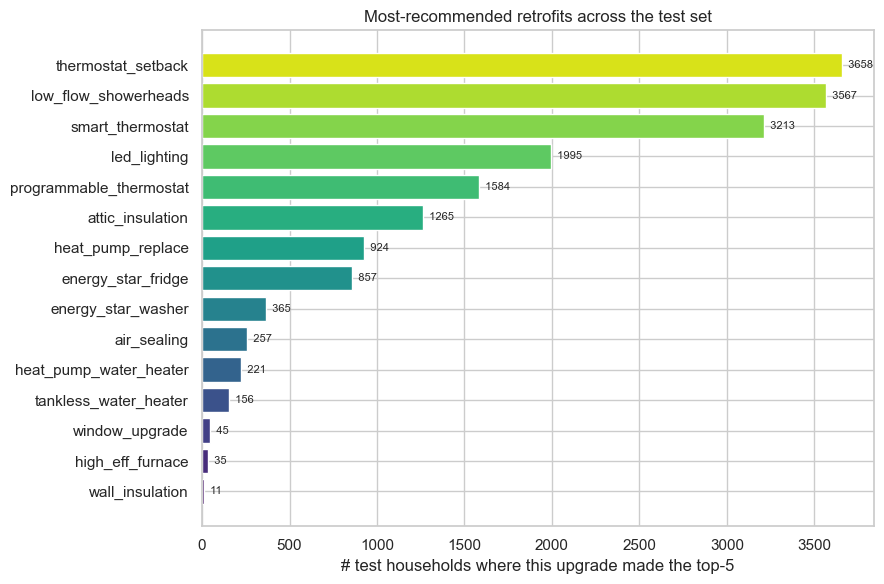

,n_homes,avg_savings,avg_payback,category,cost_midpoint_usd
upgrade_id,,,,,
thermostat_setback,3658,66.78,0.00,Behavioral,0
low_flow_showerheads,3567,22.99,5.56,Water Heating,80
smart_thermostat,3213,71.27,5.84,Behavioral,200
led_lighting,1995,57.96,8.74,Lighting,200
programmable_thermostat,1584,54.22,4.08,Behavioral,90
attic_insulation,1265,144.85,27.09,Insulation,2300
heat_pump_replace,924,301.81,38.56,HVAC,8000
energy_star_fridge,857,224.49,9.16,Appliance,1500
energy_star_washer,365,417.96,3.12,Appliance,950


In [11]:
# Frequency: which upgrades show up most in households' top-5 lists?
freq = top5.groupby('upgrade_id').agg(
    n_homes=('DOEID', 'count'),
    avg_savings=('annual_savings', 'mean'),
    avg_payback=('payback_years', 'mean'),
).join(upgrades.set_index('upgrade_id')[['category','cost_midpoint_usd']])
freq = freq.sort_values('n_homes', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette('viridis', n_colors=len(freq))
ax.barh(freq.index, freq['n_homes'], color=colors)
ax.set_xlabel('# test households where this upgrade made the top-5')
ax.set_title('Most-recommended retrofits across the test set')
for i, v in enumerate(freq['n_homes']):
    ax.text(v, i, f'  {v}', va='center', fontsize=8)
plt.tight_layout()
plt.show()
freq.sort_values('n_homes', ascending=False)


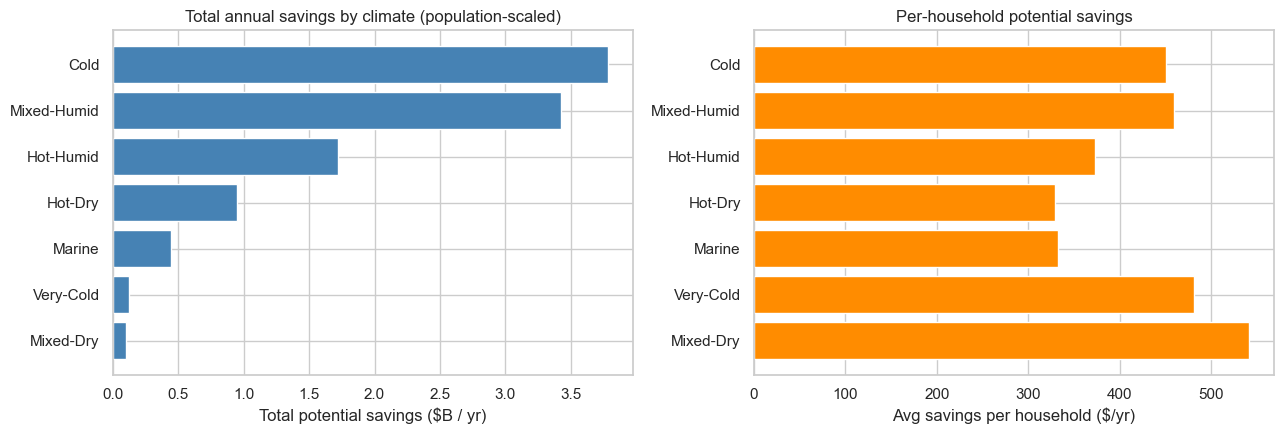

,weighted_save,n_test,n_weighted,per_household
BA_climate_grp,,,,
Mixed-Dry,"95,991,759.79",28,"177,220.66",541.65
Very-Cold,"121,516,596.53",125,"252,231.61",481.77
Marine,"441,813,568.70",183,"1,327,489.42",332.82
Hot-Dry,"948,001,904.80",315,"2,876,339.16",329.59
Hot-Humid,"1,720,647,907.02",510,"4,614,318.45",372.89
Mixed-Humid,"3,424,200,838.84",1116,"7,455,036.50",459.31
Cold,"3,786,016,360.73",1422,"8,406,589.63",450.36


In [12]:
# Annual savings by climate group (population-weighted)
clim = (hh.assign(weighted_save=hh['top5_annual_savings'] * hh['NWEIGHT'])
          .groupby('BA_climate_grp', observed=True)
          .agg(weighted_save=('weighted_save', 'sum'),
               n_test=('DOEID', 'count'),
               n_weighted=('NWEIGHT', 'sum'))
          .sort_values('weighted_save', ascending=True))
clim['per_household'] = clim['weighted_save'] / clim['n_weighted']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(clim.index, clim['weighted_save']/1e9, color='steelblue')
axes[0].set_xlabel('Total potential savings ($B / yr)')
axes[0].set_title('Total annual savings by climate (population-scaled)')
axes[1].barh(clim.index, clim['per_household'], color='darkorange')
axes[1].set_xlabel('Avg savings per household ($/yr)')
axes[1].set_title('Per-household potential savings')
plt.tight_layout()
plt.show()
clim


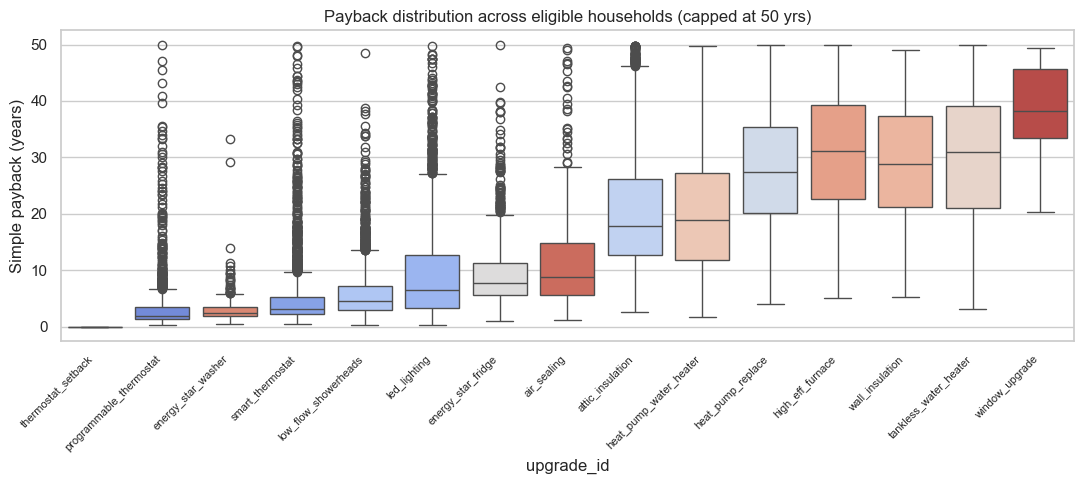

In [13]:
# Payback distribution per upgrade
fig, ax = plt.subplots(figsize=(11, 5))
order = (eligible.groupby('upgrade_id')['payback_years'].median()
                  .sort_values().index.tolist())
plot_df = eligible[eligible['payback_years'] < 50]   # cap visual outliers
sns.boxplot(data=plot_df, x='upgrade_id', y='payback_years', order=order,
            hue='upgrade_id', palette='coolwarm', legend=False, ax=ax)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Simple payback (years)')
ax.set_title('Payback distribution across eligible households (capped at 50 yrs)')
plt.tight_layout()
plt.show()


## Per-efficiency-class breakdown

Recommendations should disproportionately help the **inefficient** class (largest absolute savings) while still offering meaningful actions to the average class. Efficient households should see fewer / smaller-impact retrofits.

In [14]:
by_class = (hh.assign(weighted_save=hh['top5_annual_savings'] * hh['NWEIGHT'])
              .groupby('efficiency_class', observed=True)
              .agg(weighted_save=('weighted_save','sum'),
                   per_household=('top5_annual_savings','mean'),
                   per_household_share=('savings_share_of_bill','mean'),
                   n=('DOEID','count')))
by_class = by_class.reindex(['efficient','average','inefficient'])
print(by_class)


                    weighted_save  per_household  per_household_share     n
efficiency_class                                                           
efficient        2,745,048,170.91         373.15                 0.23  1234
average          3,534,351,292.68         456.05                 0.22  1232
inefficient      4,258,789,472.82         516.97                 0.21  1233


In [15]:
# Top-3 most-common upgrade per class
top_per_class = (top5.merge(test[['DOEID','efficiency_class']], on='DOEID')
                     .groupby(['efficiency_class','upgrade_id'], observed=True)
                     .size().reset_index(name='n')
                     .sort_values(['efficiency_class','n'], ascending=[True, False]))
top_per_class.groupby('efficiency_class', observed=True).head(3)


,efficiency_class,upgrade_id,n
12,efficient,thermostat_setback,1217
8,efficient,low_flow_showerheads,1186
10,efficient,smart_thermostat,1031
27,average,thermostat_setback,1224
23,average,low_flow_showerheads,1190
25,average,smart_thermostat,1084
42,inefficient,thermostat_setback,1217
38,inefficient,low_flow_showerheads,1191
40,inefficient,smart_thermostat,1098


## Save recommendation outputs

In [16]:
os.makedirs(MODELS_DIR, exist_ok=True)

# Per-household top-5 (long form)
top5_path = os.path.join(MODELS_DIR, 'recommendations_top5.csv')
top5.to_csv(top5_path, index=False)
print('saved:', top5_path, top5.shape)

# Household-level summary (one row per household)
hh_path = os.path.join(MODELS_DIR, 'recommendations_household_summary.csv')
hh.to_csv(hh_path, index=False)
print('saved:', hh_path, hh.shape)

# Catalog-level frequency / impact
freq_path = os.path.join(MODELS_DIR, 'recommendations_upgrade_frequency.csv')
freq.to_csv(freq_path)
print('saved:', freq_path, freq.shape)


saved: ../models/recommendations_top5.csv (18153, 9)
saved: ../models/recommendations_household_summary.csv (3699, 8)
saved: ../models/recommendations_upgrade_frequency.csv (15, 5)


## Summary

- Built an end-to-end retrofit recommender that consumes the GBR regression predictions from notebook 04.
- Compiled 15 catalog rules into pandas masks via a small custom DSL (`IN`, `AND`, `OR`, comparisons).
- Computed simple-payback rankings using **end-use-specific** savings (insulation hits `heat_cool_dol`, LED hits `lighting_dol`, etc.) so dollar figures are physically defensible rather than handwaved.
- Each test household receives up to 5 recommendations; population-scaled potential savings are reported by climate group and by efficiency class.

Outputs persisted to `models/`:
- `recommendations_top5.csv` — household × upgrade long form
- `recommendations_household_summary.csv` — household-level totals
- `recommendations_upgrade_frequency.csv` — catalog-level impact

Notebook **06** synthesizes accuracy, error, and recommendation results into a single discussion + writes the project README.